In [1]:
pip install pandas sqlalchemy pymysql scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.7 MB/s eta 0:00:00


# Koneksi ke Database Aiven

In [2]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [ ]:
# Database connection parameters
db_user = 'your_username'
db_password = 'your_password'
db_host = 'localhost'
db_name = 'your_database'

In [4]:
# Mengambil data dari Aiven

import pandas as pd

query = """
SELECT *
FROM produktivitas_padi_cuaca
"""

df = pd.read_sql(query, engine)

print(df.shape)
df.head()

(2907, 10)


,id,Wilayah,Tahun,Bulan,Produksi_Padi,Luas_Panen,Produktivitas_Ton_Ha,Suhu_4Bln,Curah_4Bln,Kelembapan_4Bln
0,1,Kabupaten Bangkalan,2018,April,27021.81,4477.0,6.035696,25.918005,1322.3,87.093126
1,2,Kabupaten Bangkalan,2018,Mei,12847.50,2218.0,5.792381,26.336553,999.6,84.004416
2,3,Kabupaten Bangkalan,2018,Juni,27605.63,4760.0,5.799502,26.732446,648.8,80.619892
3,4,Kabupaten Bangkalan,2018,Juli,37426.82,6435.0,5.816134,26.984059,212.9,75.877957
4,5,Kabupaten Bangkalan,2018,Agustus,10502.98,1811.0,5.799547,27.063145,87.5,71.504301


# Membuat Target

In [5]:
# Pembuatan target klasifikasi untuk menghitung nilai tengah dari Produktivitas_Ton_Ha
median_prod = df['Produktivitas_Ton_Ha'].median()

median_prod

# Membuat Kategori Produktivitas menjadi 2 kategori
df['Kategori_Produktivitas'] = (
    df['Produktivitas_Ton_Ha']
    >= median_prod
).astype(int)

In [6]:
df.head()

,id,Wilayah,Tahun,Bulan,Produksi_Padi,Luas_Panen,Produktivitas_Ton_Ha,Suhu_4Bln,Curah_4Bln,Kelembapan_4Bln,Kategori_Produktivitas
0,1,Kabupaten Bangkalan,2018,April,27021.81,4477.0,6.035696,25.918005,1322.3,87.093126,1
1,2,Kabupaten Bangkalan,2018,Mei,12847.50,2218.0,5.792381,26.336553,999.6,84.004416,1
2,3,Kabupaten Bangkalan,2018,Juni,27605.63,4760.0,5.799502,26.732446,648.8,80.619892,1
3,4,Kabupaten Bangkalan,2018,Juli,37426.82,6435.0,5.816134,26.984059,212.9,75.877957,1
4,5,Kabupaten Bangkalan,2018,Agustus,10502.98,1811.0,5.799547,27.063145,87.5,71.504301,1


In [ ]:
# Menghitung baris Kategori TInggi dan Rendah
df['Kategori_Produktivitas'].value_counts()

Kategori_Produktivitas
1    1454
0    1453
Name: count, dtype: int64

# Menentukan Feature dan Target
Menentukan variabel feature (X) dan target (y) yang akan digunakan pada proses pelatihan model Machine Learning.

In [ ]:
# Menentukan Featur(Input) Target(Output)
X = df[
    [
        'Suhu_4Bln',
        'Curah_4Bln',
        'Kelembapan_4Bln'
    ]
]

y = df['Kategori_Produktivitas']

# Split dataset

In [ ]:
# Membagi dataset menjadi data latih (80%) dan data uji (20%).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest

In [ ]:
# Membangun model klasifikasi produktivitas padi menggunakan algoritma Random Forest Classifier.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

# Evaluasi Model
Mengukur tingkat ketepatan model Random Forest dalam mengklasifikasikan produktivitas padi.

In [ ]:
# Menggunakan model Random Forest yang sudah dilatih untuk memprediksi data testing.
y_pred = rf.predict(X_test)

# Mengukur persentase prediksi yang benar.
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 67.87%


In [ ]:
# Menampilkan metrik evaluasi yang lebih lengkap dibanding accuracy.
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.65      0.76      0.70       291
           1       0.71      0.60      0.65       291

    accuracy                           0.68       582
   macro avg       0.68      0.68      0.68       582
weighted avg       0.68      0.68      0.68       582



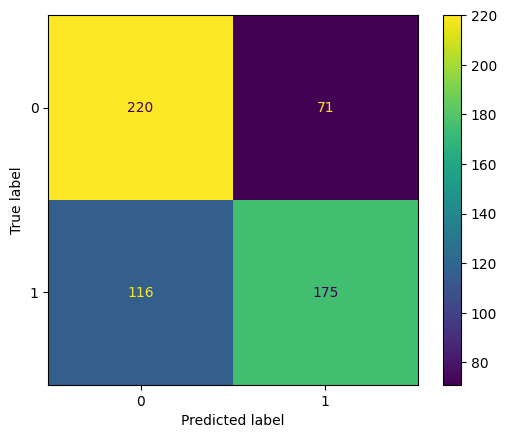

In [ ]:
# Memvisualisasikan hasil prediksi model dan mengetahui jumlah prediksi yang benar maupun salah pada setiap kategori produktivitas.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

# Analisis Faktor Cuaca

In [ ]:
# Mengetahui tingkat pengaruh masing-masing faktor cuaca terhadap produktivitas padi berdasarkan hasil pelatihan model Random Forest.
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Fitur,Importance
0,Suhu_4Bln,0.372342
2,Kelembapan_4Bln,0.337317
1,Curah_4Bln,0.290341


# Tabel Prediksi
Membuat tabel hasil prediksi produktivitas padi berdasarkan faktor cuaca menggunakan model Random Forest yang telah dilatih.

In [ ]:
# menyiapkan data yang akan diberikan ke model untuk diprediksi.
hasil_ml = (
    df.groupby(
        ['Wilayah', 'Bulan']
    )[
        [
            'Suhu_4Bln',
            'Curah_4Bln',
            'Kelembapan_4Bln'
        ]
    ]
    .mean()
    .reset_index()
)

In [ ]:
# Menggunakan model Random Forest yang sudah dilatih untuk melakuka prediksi
hasil_ml['Prediksi_Produktivitas'] = (
    rf.predict(
        hasil_ml[
            [
                'Suhu_4Bln',
                'Curah_4Bln',
                'Kelembapan_4Bln'
            ]
        ]
    )
)

In [ ]:
# Mengubah hasil prediksi dari 0 dan 1 menjadi TInggi dan Rendah
hasil_ml['Prediksi_Produktivitas'] = (
    hasil_ml['Prediksi_Produktivitas']
    .map({
        0: 'Rendah',
        1: 'Tinggi'
    })
)

hasil_ml.head()

,Wilayah,Bulan,Suhu_4Bln,Curah_4Bln,Kelembapan_4Bln,Prediksi_Produktivitas
0,Kabupaten Bangkalan,Agustus,26.932339,222.614286,74.956759,Rendah
1,Kabupaten Bangkalan,April,26.038030,1399.642857,87.557294,Rendah
2,Kabupaten Bangkalan,Desember,27.821478,773.000000,74.536649,Tinggi
3,Kabupaten Bangkalan,Februari,26.551637,1177.766667,82.115569,Rendah
4,Kabupaten Bangkalan,Januari,27.053457,981.240000,78.646452,Tinggi


# Mengurutkan Agar sesuai dengan Urutan Bulan Kalender

In [ ]:
urutan_bulan = {
    'Januari': 1,
    'Februari': 2,
    'Maret': 3,
    'April': 4,
    'Mei': 5,
    'Juni': 6,
    'Juli': 7,
    'Agustus': 8,
    'September': 9,
    'Oktober': 10,
    'November': 11,
    'Desember': 12
}

hasil_ml['Bulan_Angka'] = (
    hasil_ml['Bulan']
    .map(urutan_bulan)
)

In [ ]:
hasil_ml = hasil_ml.sort_values(
    by=['Wilayah', 'Bulan_Angka']
)

In [ ]:
hasil_ml = hasil_ml.drop(
    columns=['Bulan_Angka']
)

hasil_ml.head()

,Wilayah,Bulan,Suhu_4Bln,Curah_4Bln,Kelembapan_4Bln,Prediksi_Produktivitas
4,Kabupaten Bangkalan,Januari,27.053457,981.240000,78.646452,Tinggi
3,Kabupaten Bangkalan,Februari,26.551637,1177.766667,82.115569,Rendah
7,Kabupaten Bangkalan,Maret,26.151368,1443.433333,85.978203,Tinggi
1,Kabupaten Bangkalan,April,26.038030,1399.642857,87.557294,Rendah
8,Kabupaten Bangkalan,Mei,26.291671,1177.942857,86.437747,Rendah


# Simpan Ke Database Aiven

In [ ]:
from sqlalchemy import text

with engine.begin() as conn:

    conn.execute(text("""
    CREATE TABLE hasil_prediksi_rf (
        id INT AUTO_INCREMENT PRIMARY KEY,
        Wilayah VARCHAR(100),
        Bulan VARCHAR(20),
        Suhu_4Bln DOUBLE,
        Curah_4Bln DOUBLE,
        Kelembapan_4Bln DOUBLE,
        Prediksi_Produktivitas VARCHAR(20)
    )
    """))

print("Tabel berhasil dibuat")

Tabel berhasil dibuat


In [ ]:
pd.read_sql(
    "SHOW TABLES",
    engine
)

,Tables_in_defaultdb
0,hasil_prediksi_rf
1,produksi_padi_cuaca
2,produktivitas_padi_cuaca
3,test_padi


In [ ]:
hasil_ml.to_sql(
    'hasil_prediksi_rf',
    con=engine,
    if_exists='append',
    index=False
)

print("Data berhasil diupload")

Data berhasil diupload


In [ ]:
pd.read_sql(
    """
    SELECT *
    FROM hasil_prediksi_rf
    LIMIT 10
    """,
    engine
)

,id,Wilayah,Bulan,Suhu_4Bln,Curah_4Bln,Kelembapan_4Bln,Prediksi_Produktivitas
0,1,Kabupaten Bangkalan,Januari,27.053457,981.240000,78.646452,Tinggi
1,2,Kabupaten Bangkalan,Februari,26.551637,1177.766667,82.115569,Rendah
2,3,Kabupaten Bangkalan,Maret,26.151368,1443.433333,85.978203,Tinggi
3,4,Kabupaten Bangkalan,April,26.038030,1399.642857,87.557294,Rendah
4,5,Kabupaten Bangkalan,Mei,26.291671,1177.942857,86.437747,Rendah
5,6,Kabupaten Bangkalan,Juni,26.557001,845.785714,83.621505,Rendah
6,7,Kabupaten Bangkalan,Juli,26.725204,462.842857,79.486713,Rendah
7,8,Kabupaten Bangkalan,Agustus,26.932339,222.614286,74.956759,Rendah
8,9,Kabupaten Bangkalan,September,27.162684,150.571429,71.506528,Tinggi
9,10,Kabupaten Bangkalan,Oktober,27.573790,198.216667,69.581228,Tinggi
